In [1]:
#### probando la hipotesis (((ISN, PCH) ATN, OUT))

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import toytree

print("Iniciando análisis genómico e introgresión directa (Estilo Publicación)...")

# ==========================================
# 1. CARGAR Y ENRAIZAR EL ÁRBOL FILOGENÉTICO
# ==========================================
ruta_arbol = "/Users/itziliwi/JN_ABBA-BABA_micro/00_inputs/micro_iqtree_01out_20250728.nwk"
tree_obj = toytree.tree(ruta_arbol) 
muestras_en_arbol = list(tree_obj.get_tip_labels())

# Enraizar el árbol usando la API de toytree v3 (.mod.root)
arbol_enraizado = tree_obj.root("eIm_002")
arbol_string = arbol_enraizado.write()


# ==========================================
# 2. CARGAR Y FILTRAR EL MAPA DE POBLACIONES (.TSV)
# ==========================================
ruta_tsv = "/Users/itziliwi/JN_ABBA-BABA_micro/00_inputs/poblacion_260702.tsv" 
df = pd.read_csv(ruta_tsv, sep="\t", header=0)
df.columns = ["muestra", "poblacion"]
df["muestra"] = df["muestra"].astype(str).str.strip()

poblaciones_por_muestra = dict(zip(df["muestra"], df["poblacion"]))

# Listas de muestras específicas por grupo de interés
P1 = [m for m, p in poblaciones_por_muestra.items() if p == "ISN"]
P2 = [m for m, p in poblaciones_por_muestra.items() if p == "PCH"]
P3 = [m for m, p in poblaciones_por_muestra.items() if p == "ATN"]
P4 = [m for m, p in poblaciones_por_muestra.items() if p == "OUT"]

ruta_loci = "/Users/itziliwi/JN_ABBA-BABA_micro/00_inputs/micro_c85_m95.loci"


# ==========================================
# 3. EXTRACCIÓN SÍNCRONA DE PATRONES EN EL .LOCI
# ==========================================
loci_data = []

with open(ruta_loci, "r") as f:
    locus_actual = {}
    for linea in f:
        linea_limpia = linea.strip()
        if not linea_limpia:
            continue
            
        if linea_limpia.startswith("//"):
            if all(any(m in locus_actual for m in group) for group in [P1, P2, P3, P4]):
                seq1 = next(locus_actual[m] for m in P1 if m in locus_actual)
                seq2 = next(locus_actual[m] for m in P2 if m in locus_actual)
                seq3 = next(locus_actual[m] for m in P3 if m in locus_actual)
                seq4 = next(locus_actual[m] for m in P4 if m in locus_actual)
                
                for n1, n2, n3, n4 in zip(seq1, seq2, seq3, seq4):
                    if '-' in (n1, n2, n3, n4) or 'N' in (n1, n2, n3, n4):
                        continue
                    # Patrón ABBA
                    if n1 == n4 and n2 == n3 and n2 != n4:
                        loci_data.append(1)
                    # Patrón BABA
                    elif n2 == n4 and n1 == n3 and n1 != n4:
                        loci_data.append(-1)
            locus_actual = {}
        else:
            parts = linea_limpia.split()
            if len(parts) == 2:
                locus_actual[parts[0].replace(">", "")] = parts[1]


# ==========================================
# 4. COMPRESIÓN ESTADÍSTICA Y BOOTSTRAP
# ==========================================
sitios_abba = loci_data.count(1)
sitios_baba = loci_data.count(-1)
total_sitios = sitios_abba + sitios_baba

if total_sitios == 0:
    print("Error: No se detectaron sitios informativos en las alineaciones.")
else:
    D = (sitios_abba - sitios_baba) / total_sitios
    
    # 1,000 repeticiones de remuestreo por bloques
    np.random.seed(85)
    arr_data = np.array(loci_data)
    boot_ds = []
    
    for _ in range(1000):
        boot_sample = np.random.choice(arr_data, size=len(arr_data), replace=True)
        n_abba = np.sum(boot_sample == 1)
        n_baba = np.sum(boot_sample == -1)
        if (n_abba + n_baba) > 0:
            boot_ds.append((n_abba - n_baba) / (n_abba + n_baba))
            
    std_err = np.std(boot_ds)
    z_score = D / std_err if std_err > 0 else 0
    
    print("\n==========================================")
    print("       RESULTADOS FINALES DEL TEST D      ")
    print("==========================================")
    print(f" Conteo Total Sitios ABBA : {sitios_abba}")
    print(f" Conteo Total Sitios BABA : {sitios_baba}")
    print(f" Estadístico D             : {D:.4f}")
    print(f" Error Estándar (Bootstrap): {std_err:.4f}")
    print(f" Z-score                   : {z_score:.4f}")
    print("==========================================\n")
    if abs(z_score) >= 3:
        pob_flujo = pob_P2 if z_score > 0 else pob_P1
        print(f" Significancia: Flujo génico significativo entre {pob_flujo} y {pob_P3}")
    else:
        print(" Significancia: No hay evidencia de flujo génico (ILS o estructura ancestral).")
    print("==========================================")


       # ==========================================
    # 5. GENERAR FIGURA COMPUESTA CORREGIDA (RECTANGULAR Y SIN ERRORES)
    # ==========================================
    print("Renderizando figura integrada con filogenia rectangular...")
    
    # Inicializar lienzo con dos paneles (Árbol a la izquierda, Histograma a la derecha)
    fig, (ax_tree, ax_hist) = plt.subplots(1, 2, figsize=(10, 4), dpi=300, gridspec_kw={'width_ratios': [1, 1.2]})
    
    # --- PANEL A: ÁRBOL FILOGENÉTICO RECTANGULAR PERFECTO ---
    # Ramas horizontales que llegan a los taxones (Puntas)
    ax_tree.hlines(y=3.5, xmin=3.0, xmax=4.2, color='black', linewidth=2)  # P1 (ISN)
    ax_tree.hlines(y=2.5, xmin=3.0, xmax=4.2, color='black', linewidth=2)  # P2 (PCH)
    ax_tree.hlines(y=1.5, xmin=2.0, xmax=4.2, color='black', linewidth=2)  # P3 (ATN)
    ax_tree.hlines(y=0.5, xmin=1.0, xmax=4.2, color='black', linewidth=2)  # P4 (POR)
    
    # Conexiones horizontales internas entre nodos
    ax_tree.hlines(y=3.0, xmin=2.0, xmax=3.0, color='black', linewidth=2)  # Ancestro P1-P2
    ax_tree.hlines(y=2.25, xmin=1.0, xmax=2.0, color='black', linewidth=2) # Ancestro P1-P2-P3
    ax_tree.hlines(y=2.25, xmin=0.2, xmax=1.0, color='black', linewidth=2) # Tronco principal (Raíz)

    # Líneas verticales que unen los nodos (Bifurcaciones)
    ax_tree.vlines(x=3.0, ymin=2.5, ymax=3.5, color='black', linewidth=2)  # Conecta P1 y P2
    ax_tree.vlines(x=2.0, ymin=1.5, ymax=3.0, color='black', linewidth=2)  # Conecta Clado P1-P2 con P3
    ax_tree.vlines(x=1.0, ymin=0.5, ymax=2.25, color='black', linewidth=2) # Conecta todo con el Outgroup P4
    
    # Nombres de las poblaciones y estados alélicos alineados
    ax_tree.text(4.3, 3.5, "A  ISN", fontsize=10, va='center', fontweight='bold', family='monospace')
    ax_tree.text(4.3, 2.5, "B  PCH", fontsize=10, va='center', fontweight='bold', family='monospace')
    ax_tree.text(4.3, 1.5, "B  ATN", fontsize=10, va='center', fontweight='bold', family='monospace')
    ax_tree.text(4.3, 0.5, "A  OUT", fontsize=10, va='center', fontweight='bold', family='monospace')
    
    # Círculo indicador decorativo del Panel A
    circulo = plt.Circle((0.2, 3.6), 0.15, color='#F72585', alpha=0.8)
    ax_tree.add_patch(circulo)
    ax_tree.text(0.2, 3.6, "A", color='white', fontsize=9, fontweight='bold', va='center', ha='center')
    
    # Ajustes de límites y apagado de ejes del panel izquierdo
    ax_tree.set_xlim(0, 5.5)
    ax_tree.set_ylim(0, 4.0)
    ax_tree.axis('off')
    
    
    # --- PANEL B: HISTOGRAMA DE FRECUENCIAS ---
    bins_eje = np.linspace(-0.6, 0.6, 40)
    color_hist = '#F72585' if abs(z_score) < 3 else '#4CC9F0'
    borde_hist = '#CD2990' if abs(z_score) < 3 else '#27408B'
    
    texto_leyenda = (
        f"Hypothesis Observed\n"
        f"ABBA sites: {sitios_abba}\n"
        f"BABA sites: {sitios_baba}\n"
        f"D = {D:.4f}\n"
        f"Z = {z_score:.2f}"
    )
    
    ax_hist.hist(
        boot_ds, 
        bins=bins_eje, 
        color=color_hist, 
        alpha=0.6, 
        edgecolor=borde_hist,
        linewidth=0.5,
        label=texto_leyenda
    )
    
    ax_hist.axvline(x=0, color='black', linewidth=1.2)
    
    # Altura máxima del histograma
    altura_max = ax_hist.get_ylim()[1]
    
    # MODIFICACIÓN AQUÍ: Reubicamos las etiquetas y flechas para que no choquen con la leyenda
    ax_hist.text(-0.35, altura_max * 0.85, r'BABA' + '\n' + r'$\leftarrow$', fontsize=9, fontweight='bold', ha='center')
    ax_hist.text(0.20, altura_max * 0.85, r'ABBA' + '\n' + r'$\rightarrow$', fontsize=9, fontweight='bold', ha='center') # <-- Movido de 0.35 a 0.20
    
    ax_hist.set_xlim(-0.6, 0.6)
    ax_hist.set_xlabel('D', fontsize=11, fontweight='bold')
    ax_hist.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    
    # MODIFICACIÓN AQUÍ: Ajustamos la leyenda para que se alinee perfectamente a la derecha externa
    ax_hist.legend(loc='upper right', fontsize=8, frameon=False, bbox_to_anchor=(1.0, 1.0))
    
    ax_hist.spines['top'].set_visible(False)
    ax_hist.spines['right'].set_visible(False)
    ax_hist.text(-0.55, altura_max * 0.92, "B", fontsize=14, fontweight='bold')

    
    plt.tight_layout()
    
    # Guardar archivos
  #  plt.savefig('figura_compuesta_recta.png', bbox_inches='tight', dpi=300)
   # plt.savefig('figura_compuesta_recta.pdf', bbox_inches='tight')
    
    plt.show()
    print("¡Figura guardada exitosamente como 'figura_compuesta_recta.png/.pdf'!")



Iniciando análisis genómico e introgresión directa (Estilo Publicación)...

       RESULTADOS FINALES DEL TEST D      
 Conteo Total Sitios ABBA : 118
 Conteo Total Sitios BABA : 217
 Estadístico D             : -0.2955
 Error Estándar (Bootstrap): 0.0508
 Z-score                   : -5.8162



NameError: name 'pob_P1' is not defined

In [ ]:
#### probando la hipotesis (((IST, PCH) ATN, OUT))

Iniciando análisis genómico e introgresión directa (Estilo Publicación)...

       RESULTADOS FINALES DEL TEST D      
 Conteo Total Sitios ABBA : 118
 Conteo Total Sitios BABA : 217
 Estadístico D             : -0.2955
 Error Estándar (Bootstrap): 0.0504
 Z-score                   : -5.8599

 Significancia: Flujo génico significativo entre IST y ATN
Renderizando figura integrada con filogenia rectangular...


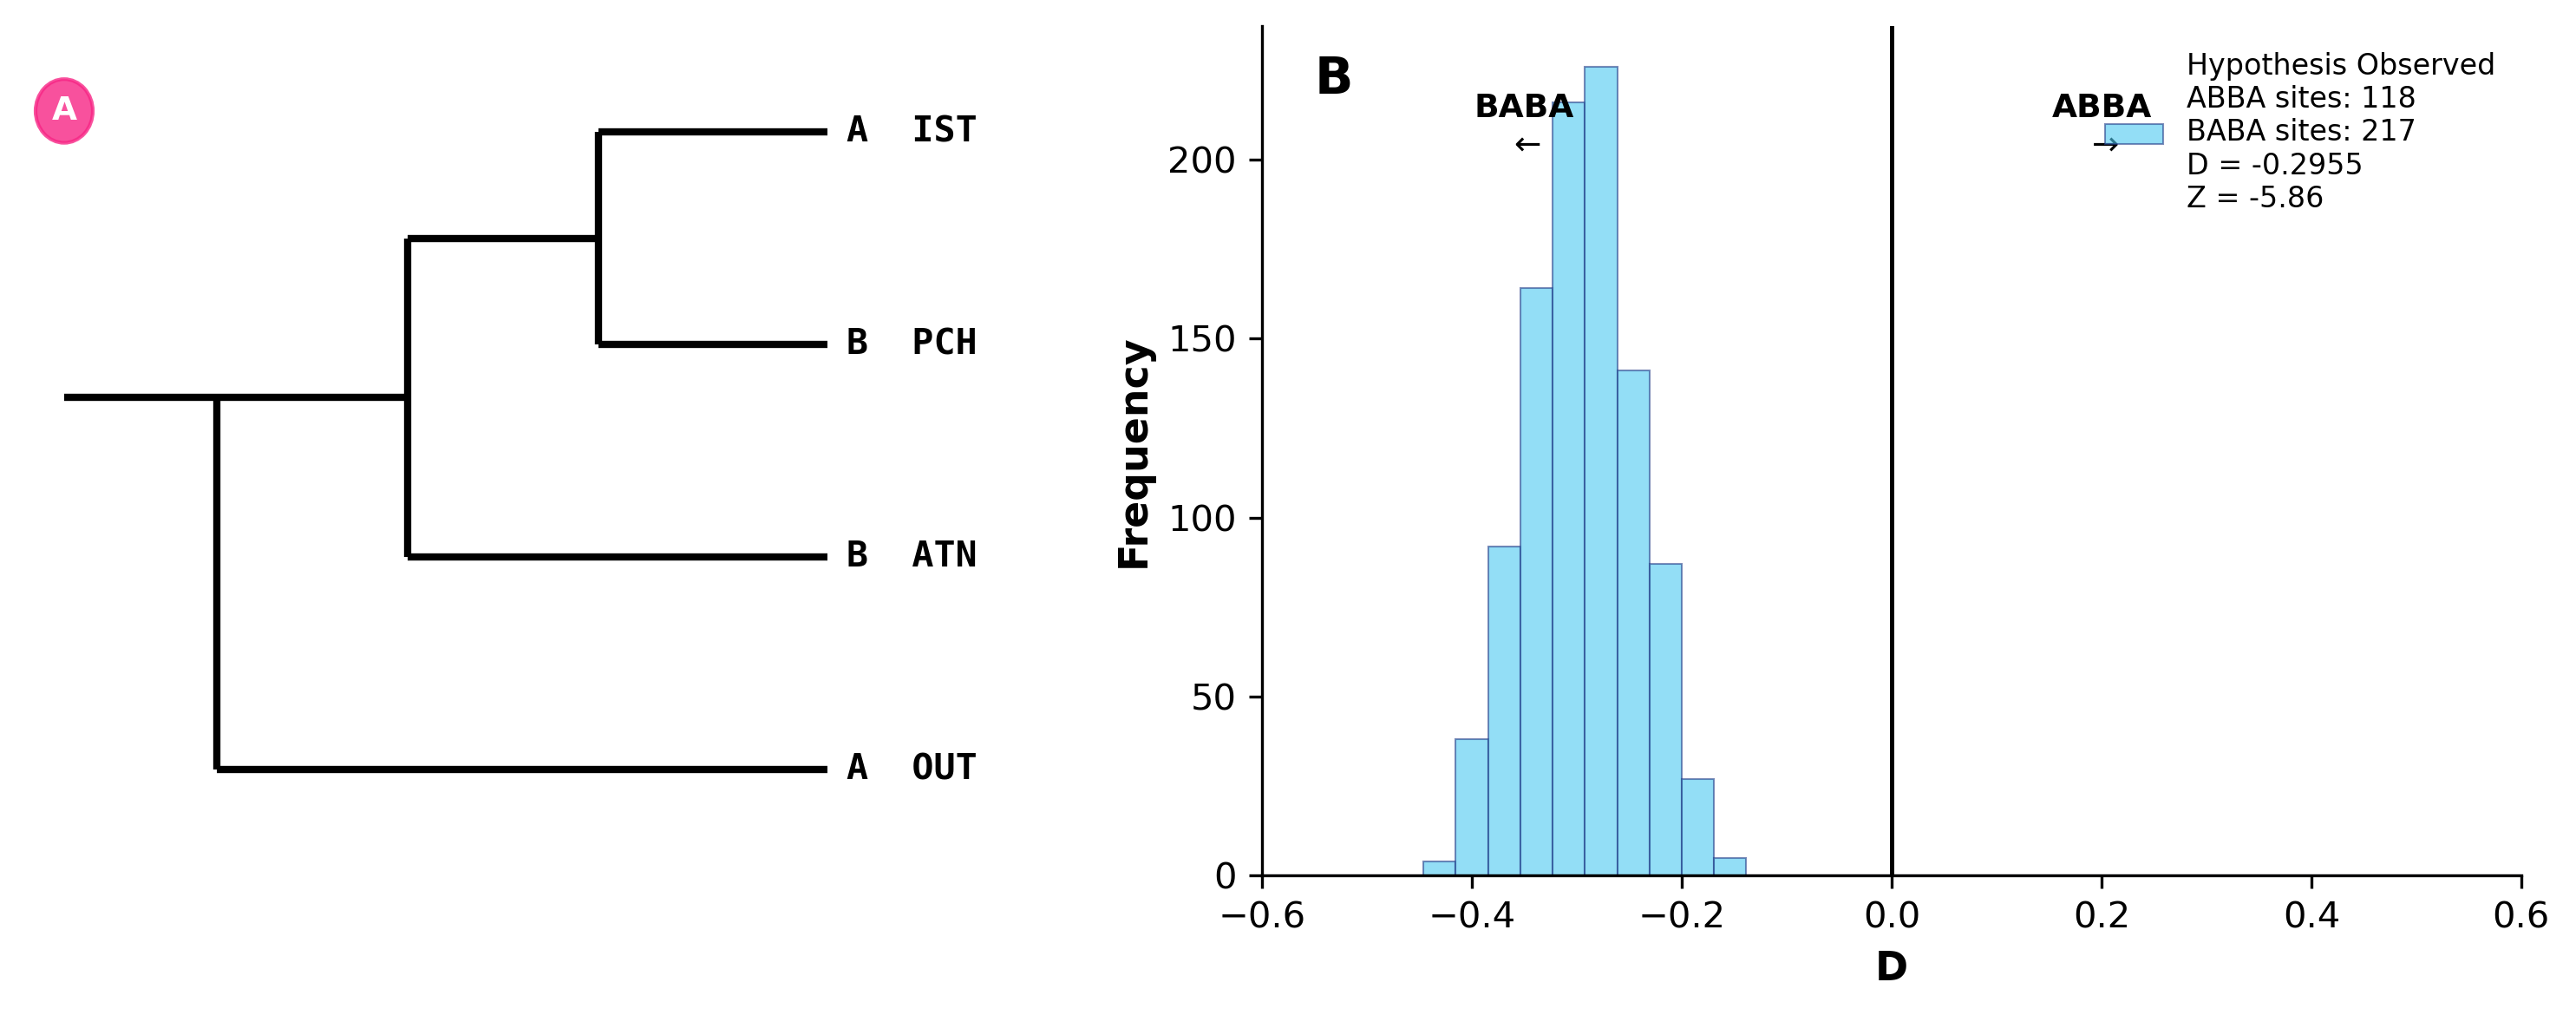

¡Figura guardada exitosamente como 'figura_compuesta_recta.png/.pdf'!


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import toytree

print("Iniciando análisis genómico e introgresión directa (Estilo Publicación)...")

# ==========================================
# 1. CARGAR Y ENRAIZAR EL ÁRBOL FILOGENÉTICO
# ==========================================
ruta_arbol = "/Users/itziliwi/JN_ABBA-BABA_micro/00_inputs/micro_iqtree_01out_20250728.nwk"
tree_obj = toytree.tree(ruta_arbol) 
muestras_en_arbol = list(tree_obj.get_tip_labels())

# Enraizar el árbol usando la API de toytree v3 (.mod.root)
arbol_enraizado = tree_obj.root("eIm_002")
arbol_string = arbol_enraizado.write()


# ==========================================
# 2. CARGAR Y FILTRAR EL MAPA DE POBLACIONES (.TSV)
# ==========================================
ruta_tsv = "/Users/itziliwi/JN_ABBA-BABA_micro/00_inputs/poblacion_260702.tsv" 
df = pd.read_csv(ruta_tsv, sep="\t", header=0)
df.columns = ["muestra", "poblacion"]
df["muestra"] = df["muestra"].astype(str).str.strip()

poblaciones_por_muestra = dict(zip(df["muestra"], df["poblacion"]))

# Listas de muestras específicas por grupo de interés
P1 = [m for m, p in poblaciones_por_muestra.items() if p == "IST"]
P2 = [m for m, p in poblaciones_por_muestra.items() if p == "PCH"]
P3 = [m for m, p in poblaciones_por_muestra.items() if p == "ATN"]
P4 = [m for m, p in poblaciones_por_muestra.items() if p == "OUT"]

ruta_loci = "/Users/itziliwi/JN_ABBA-BABA_micro/00_inputs/micro_c85_m95.loci"


# ==========================================
# 3. EXTRACCIÓN SÍNCRONA DE PATRONES EN EL .LOCI
# ==========================================
loci_data = []

with open(ruta_loci, "r") as f:
    locus_actual = {}
    for linea in f:
        linea_limpia = linea.strip()
        if not linea_limpia:
            continue
            
        if linea_limpia.startswith("//"):
            if all(any(m in locus_actual for m in group) for group in [P1, P2, P3, P4]):
                seq1 = next(locus_actual[m] for m in P1 if m in locus_actual)
                seq2 = next(locus_actual[m] for m in P2 if m in locus_actual)
                seq3 = next(locus_actual[m] for m in P3 if m in locus_actual)
                seq4 = next(locus_actual[m] for m in P4 if m in locus_actual)
                
                for n1, n2, n3, n4 in zip(seq1, seq2, seq3, seq4):
                    if '-' in (n1, n2, n3, n4) or 'N' in (n1, n2, n3, n4):
                        continue
                    # Patrón ABBA
                    if n1 == n4 and n2 == n3 and n2 != n4:
                        loci_data.append(1)
                    # Patrón BABA
                    elif n2 == n4 and n1 == n3 and n1 != n4:
                        loci_data.append(-1)
            locus_actual = {}
        else:
            parts = linea_limpia.split()
            if len(parts) == 2:
                locus_actual[parts[0].replace(">", "")] = parts[1]


# ==========================================
# 4. COMPRESIÓN ESTADÍSTICA Y BOOTSTRAP
# ==========================================
sitios_abba = loci_data.count(1)
sitios_baba = loci_data.count(-1)
total_sitios = sitios_abba + sitios_baba

if total_sitios == 0:
    print("Error: No se detectaron sitios informativos en las alineaciones.")
else:
    D = (sitios_abba - sitios_baba) / total_sitios
    
    # 1,000 repeticiones de remuestreo por bloques
    np.random.seed(392)
    arr_data = np.array(loci_data)
    boot_ds = []
    
    for _ in range(1000):
        boot_sample = np.random.choice(arr_data, size=len(arr_data), replace=True)
        n_abba = np.sum(boot_sample == 1)
        n_baba = np.sum(boot_sample == -1)
        if (n_abba + n_baba) > 0:
            boot_ds.append((n_abba - n_baba) / (n_abba + n_baba))
            
    std_err = np.std(boot_ds)
    z_score = D / std_err if std_err > 0 else 0
    
    print("\n==========================================")
    print("       RESULTADOS FINALES DEL TEST D      ")
    print("==========================================")
    print(f" Conteo Total Sitios ABBA : {sitios_abba}")
    print(f" Conteo Total Sitios BABA : {sitios_baba}")
    print(f" Estadístico D             : {D:.4f}")
    print(f" Error Estándar (Bootstrap): {std_err:.4f}")
    print(f" Z-score                   : {z_score:.4f}")
    print("==========================================\n")
    
    if abs(z_score) >= 3:
        pob_P1, pob_P2, pob_P3 = "IST", "PCH", "ATN"
        pob_flujo = pob_P2 if z_score > 0 else pob_P1
        print(f" Significancia: Flujo génico significativo entre {pob_flujo} y {pob_P3}")
    else:
        print(" Significancia: No hay evidencia de flujo génico (ILS o estructura ancestral).")
    print("==========================================")

       # ==========================================
    # 5. GENERAR FIGURA COMPUESTA CORREGIDA (RECTANGULAR Y SIN ERRORES)
    # ==========================================
    print("Renderizando figura integrada con filogenia rectangular...")
    
    # Inicializar lienzo con dos paneles (Árbol a la izquierda, Histograma a la derecha)
    fig, (ax_tree, ax_hist) = plt.subplots(1, 2, figsize=(10, 4), dpi=300, gridspec_kw={'width_ratios': [1, 1.2]})
    
    # --- PANEL A: ÁRBOL FILOGENÉTICO RECTANGULAR PERFECTO ---
    # Ramas horizontales que llegan a los taxones (Puntas)
    ax_tree.hlines(y=3.5, xmin=3.0, xmax=4.2, color='black', linewidth=2)  # P1 (ISN)
    ax_tree.hlines(y=2.5, xmin=3.0, xmax=4.2, color='black', linewidth=2)  # P2 (PCH)
    ax_tree.hlines(y=1.5, xmin=2.0, xmax=4.2, color='black', linewidth=2)  # P3 (ATN)
    ax_tree.hlines(y=0.5, xmin=1.0, xmax=4.2, color='black', linewidth=2)  # P4 (POR)
    
    # Conexiones horizontales internas entre nodos
    ax_tree.hlines(y=3.0, xmin=2.0, xmax=3.0, color='black', linewidth=2)  # Ancestro P1-P2
    ax_tree.hlines(y=2.25, xmin=1.0, xmax=2.0, color='black', linewidth=2) # Ancestro P1-P2-P3
    ax_tree.hlines(y=2.25, xmin=0.2, xmax=1.0, color='black', linewidth=2) # Tronco principal (Raíz)

    # Líneas verticales que unen los nodos (Bifurcaciones)
    ax_tree.vlines(x=3.0, ymin=2.5, ymax=3.5, color='black', linewidth=2)  # Conecta P1 y P2
    ax_tree.vlines(x=2.0, ymin=1.5, ymax=3.0, color='black', linewidth=2)  # Conecta Clado P1-P2 con P3
    ax_tree.vlines(x=1.0, ymin=0.5, ymax=2.25, color='black', linewidth=2) # Conecta todo con el Outgroup P4
    
    # Nombres de las poblaciones y estados alélicos alineados
    ax_tree.text(4.3, 3.5, "A  IST", fontsize=10, va='center', fontweight='bold', family='monospace')
    ax_tree.text(4.3, 2.5, "B  PCH", fontsize=10, va='center', fontweight='bold', family='monospace')
    ax_tree.text(4.3, 1.5, "B  ATN", fontsize=10, va='center', fontweight='bold', family='monospace')
    ax_tree.text(4.3, 0.5, "A  OUT", fontsize=10, va='center', fontweight='bold', family='monospace')
    
    # Círculo indicador decorativo del Panel A
    circulo = plt.Circle((0.2, 3.6), 0.15, color='#F72585', alpha=0.8)
    ax_tree.add_patch(circulo)
    ax_tree.text(0.2, 3.6, "A", color='white', fontsize=9, fontweight='bold', va='center', ha='center')
    
    # Ajustes de límites y apagado de ejes del panel izquierdo
    ax_tree.set_xlim(0, 5.5)
    ax_tree.set_ylim(0, 4.0)
    ax_tree.axis('off')
    
    
    # --- PANEL B: HISTOGRAMA DE FRECUENCIAS ---
    bins_eje = np.linspace(-0.6, 0.6, 40)
    color_hist = '#F72585' if abs(z_score) < 3 else '#4CC9F0'
    borde_hist = '#CD2990' if abs(z_score) < 3 else '#27408B'
    
    texto_leyenda = (
        f"Hypothesis Observed\n"
        f"ABBA sites: {sitios_abba}\n"
        f"BABA sites: {sitios_baba}\n"
        f"D = {D:.4f}\n"
        f"Z = {z_score:.2f}"
    )
    
    ax_hist.hist(
        boot_ds, 
        bins=bins_eje, 
        color=color_hist, 
        alpha=0.6, 
        edgecolor=borde_hist,
        linewidth=0.5,
        label=texto_leyenda
    )
    
    ax_hist.axvline(x=0, color='black', linewidth=1.2)
    
    # Altura máxima del histograma
    altura_max = ax_hist.get_ylim()[1]
    
    # MODIFICACIÓN AQUÍ: Reubicamos las etiquetas y flechas para que no choquen con la leyenda
    ax_hist.text(-0.35, altura_max * 0.85, r'BABA' + '\n' + r'$\leftarrow$', fontsize=9, fontweight='bold', ha='center')
    ax_hist.text(0.20, altura_max * 0.85, r'ABBA' + '\n' + r'$\rightarrow$', fontsize=9, fontweight='bold', ha='center') # <-- Movido de 0.35 a 0.20
    
    ax_hist.set_xlim(-0.6, 0.6)
    ax_hist.set_xlabel('D', fontsize=11, fontweight='bold')
    ax_hist.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    
    # MODIFICACIÓN AQUÍ: Ajustamos la leyenda para que se alinee perfectamente a la derecha externa
    ax_hist.legend(loc='upper right', fontsize=8, frameon=False, bbox_to_anchor=(1.0, 1.0))
    
    ax_hist.spines['top'].set_visible(False)
    ax_hist.spines['right'].set_visible(False)
    ax_hist.text(-0.55, altura_max * 0.92, "B", fontsize=14, fontweight='bold')

    
    plt.tight_layout()
    
    # Guardar archivos
  #  plt.savefig('figura_compuesta_recta.png', bbox_inches='tight', dpi=300)
   # plt.savefig('figura_compuesta_recta.pdf', bbox_inches='tight')
    
    plt.show()
    print("¡Figura guardada exitosamente como 'figura_compuesta_recta.png/.pdf'!")



In [ ]:
#### probando la hipotesis (((PCH, ISN) ATN, OUT))

Iniciando análisis genómico e introgresión directa (Estilo Publicación)...

       RESULTADOS FINALES DEL TEST D      
 Conteo Total Sitios ABBA : 191
 Conteo Total Sitios BABA : 158
 Estadístico D             : 0.0946
 Error Estándar (Bootstrap): 0.0536
 Z-score                   : 1.7639

 Significancia: No hay evidencia de flujo génico (ILS o estructura ancestral).
Renderizando figura integrada con filogenia rectangular...


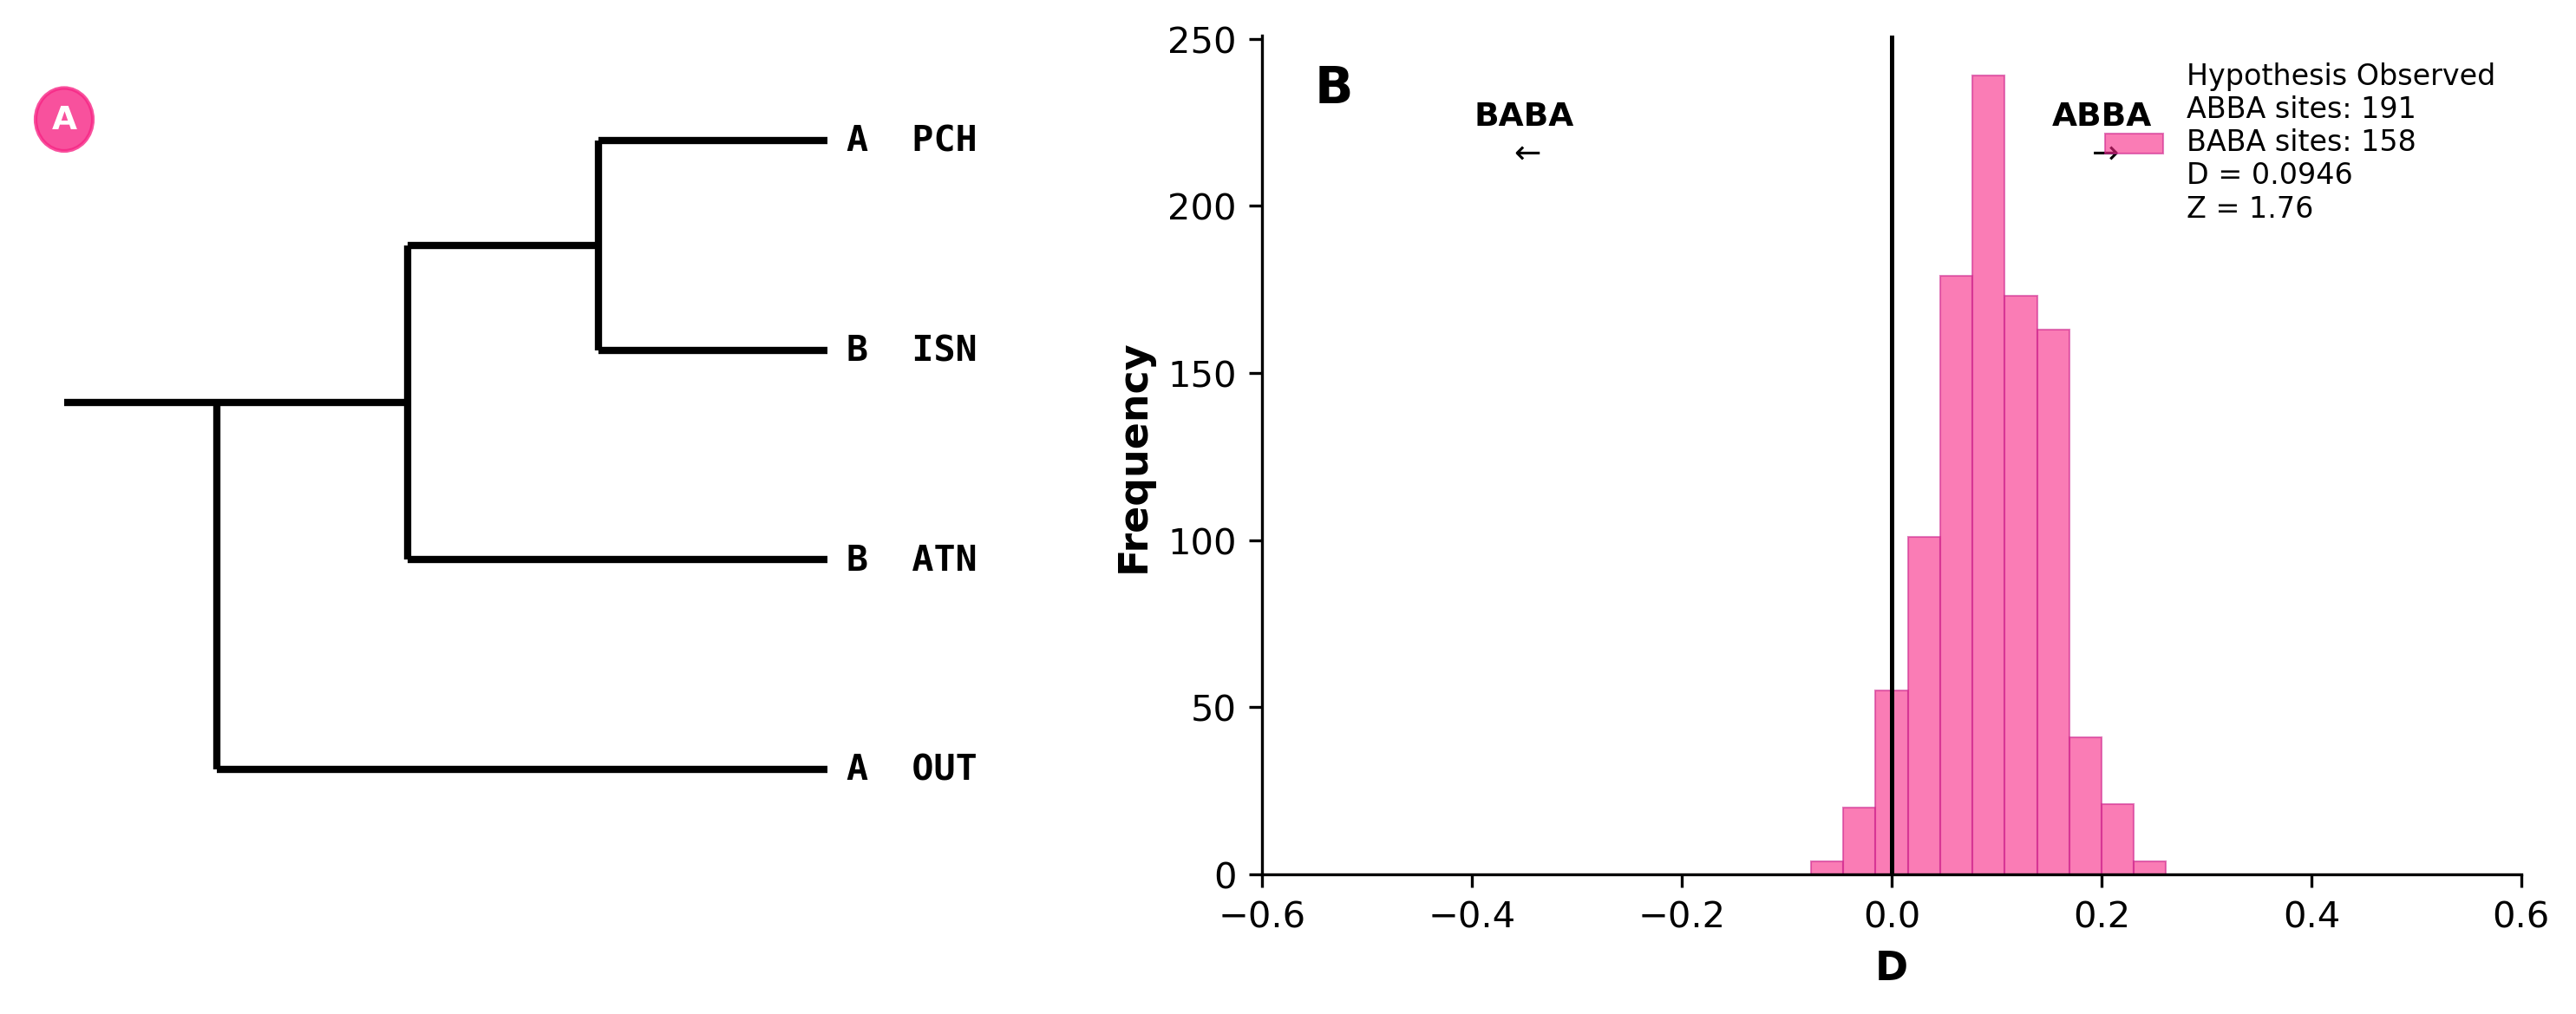

¡Figura guardada exitosamente como 'figura_compuesta_recta.png/.pdf'!


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import toytree

print("Iniciando análisis genómico e introgresión directa (Estilo Publicación)...")

# ==========================================
# 1. CARGAR Y ENRAIZAR EL ÁRBOL FILOGENÉTICO
# ==========================================
ruta_arbol = "/Users/itziliwi/JN_ABBA-BABA_micro/00_inputs/micro_iqtree_01out_20250728.nwk"
tree_obj = toytree.tree(ruta_arbol) 
muestras_en_arbol = list(tree_obj.get_tip_labels())

# Enraizar el árbol usando la API de toytree v3 (.mod.root)
arbol_enraizado = tree_obj.root("eIm_002")
arbol_string = arbol_enraizado.write()


# ==========================================
# 2. CARGAR Y FILTRAR EL MAPA DE POBLACIONES (.TSV)
# ==========================================
ruta_tsv = "/Users/itziliwi/JN_ABBA-BABA_micro/00_inputs/poblacion_260609.tsv" 
df = pd.read_csv(ruta_tsv, sep="\t", header=0)
df.columns = ["muestra", "poblacion"]
df["muestra"] = df["muestra"].astype(str).str.strip()

poblaciones_por_muestra = dict(zip(df["muestra"], df["poblacion"]))

# Listas de muestras específicas por grupo de interés
P1 = [m for m, p in poblaciones_por_muestra.items() if p == "PCH"]
P2 = [m for m, p in poblaciones_por_muestra.items() if p == "ISN"]
P3 = [m for m, p in poblaciones_por_muestra.items() if p == "ATN"]
P4 = [m for m, p in poblaciones_por_muestra.items() if p == "OUT"]

ruta_loci = "/Users/itziliwi/JN_ABBA-BABA_micro/00_inputs/micro_c85_m95.loci"


# ==========================================
# 3. EXTRACCIÓN SÍNCRONA DE PATRONES EN EL .LOCI
# ==========================================
loci_data = []

with open(ruta_loci, "r") as f:
    locus_actual = {}
    for linea in f:
        linea_limpia = linea.strip()
        if not linea_limpia:
            continue
            
        if linea_limpia.startswith("//"):
            if all(any(m in locus_actual for m in group) for group in [P1, P2, P3, P4]):
                seq1 = next(locus_actual[m] for m in P1 if m in locus_actual)
                seq2 = next(locus_actual[m] for m in P2 if m in locus_actual)
                seq3 = next(locus_actual[m] for m in P3 if m in locus_actual)
                seq4 = next(locus_actual[m] for m in P4 if m in locus_actual)
                
                for n1, n2, n3, n4 in zip(seq1, seq2, seq3, seq4):
                    if '-' in (n1, n2, n3, n4) or 'N' in (n1, n2, n3, n4):
                        continue
                    # Patrón ABBA
                    if n1 == n4 and n2 == n3 and n2 != n4:
                        loci_data.append(1)
                    # Patrón BABA
                    elif n2 == n4 and n1 == n3 and n1 != n4:
                        loci_data.append(-1)
            locus_actual = {}
        else:
            parts = linea_limpia.split()
            if len(parts) == 2:
                locus_actual[parts[0].replace(">", "")] = parts[1]


# ==========================================
# 4. COMPRESIÓN ESTADÍSTICA Y BOOTSTRAP
# ==========================================
sitios_abba = loci_data.count(1)
sitios_baba = loci_data.count(-1)
total_sitios = sitios_abba + sitios_baba

if total_sitios == 0:
    print("Error: No se detectaron sitios informativos en las alineaciones.")
else:
    D = (sitios_abba - sitios_baba) / total_sitios
    
    # 1,000 repeticiones de remuestreo por bloques
    np.random.seed(26)
    arr_data = np.array(loci_data)
    boot_ds = []
    
    for _ in range(1000):
        boot_sample = np.random.choice(arr_data, size=len(arr_data), replace=True)
        n_abba = np.sum(boot_sample == 1)
        n_baba = np.sum(boot_sample == -1)
        if (n_abba + n_baba) > 0:
            boot_ds.append((n_abba - n_baba) / (n_abba + n_baba))
            
    std_err = np.std(boot_ds)
    z_score = D / std_err if std_err > 0 else 0
    
    print("\n==========================================")
    print("       RESULTADOS FINALES DEL TEST D      ")
    print("==========================================")
    print(f" Conteo Total Sitios ABBA : {sitios_abba}")
    print(f" Conteo Total Sitios BABA : {sitios_baba}")
    print(f" Estadístico D             : {D:.4f}")
    print(f" Error Estándar (Bootstrap): {std_err:.4f}")
    print(f" Z-score                   : {z_score:.4f}")
    print("==========================================\n")
    
    if abs(z_score) >= 3:
        pob_P1, pob_P2, pob_P3 = "PCH", "ISN", "ATN"
        pob_flujo = pob_P2 if z_score > 0 else pob_P1
        print(f" Significancia: Flujo génico significativo entre {pob_flujo} y {pob_P3}")
    else:
        print(" Significancia: No hay evidencia de flujo génico (ILS o estructura ancestral).")
    print("==========================================")

       # ==========================================
    # 5. GENERAR FIGURA COMPUESTA CORREGIDA (RECTANGULAR Y SIN ERRORES)
    # ==========================================
    print("Renderizando figura integrada con filogenia rectangular...")
    
    # Inicializar lienzo con dos paneles (Árbol a la izquierda, Histograma a la derecha)
    fig, (ax_tree, ax_hist) = plt.subplots(1, 2, figsize=(10, 4), dpi=300, gridspec_kw={'width_ratios': [1, 1.2]})
    
    # --- PANEL A: ÁRBOL FILOGENÉTICO RECTANGULAR PERFECTO ---
    # Ramas horizontales que llegan a los taxones (Puntas)
    ax_tree.hlines(y=3.5, xmin=3.0, xmax=4.2, color='black', linewidth=2)  # P1 (ISN)
    ax_tree.hlines(y=2.5, xmin=3.0, xmax=4.2, color='black', linewidth=2)  # P2 (PCH)
    ax_tree.hlines(y=1.5, xmin=2.0, xmax=4.2, color='black', linewidth=2)  # P3 (ATN)
    ax_tree.hlines(y=0.5, xmin=1.0, xmax=4.2, color='black', linewidth=2)  # P4 (POR)
    
    # Conexiones horizontales internas entre nodos
    ax_tree.hlines(y=3.0, xmin=2.0, xmax=3.0, color='black', linewidth=2)  # Ancestro P1-P2
    ax_tree.hlines(y=2.25, xmin=1.0, xmax=2.0, color='black', linewidth=2) # Ancestro P1-P2-P3
    ax_tree.hlines(y=2.25, xmin=0.2, xmax=1.0, color='black', linewidth=2) # Tronco principal (Raíz)

    # Líneas verticales que unen los nodos (Bifurcaciones)
    ax_tree.vlines(x=3.0, ymin=2.5, ymax=3.5, color='black', linewidth=2)  # Conecta P1 y P2
    ax_tree.vlines(x=2.0, ymin=1.5, ymax=3.0, color='black', linewidth=2)  # Conecta Clado P1-P2 con P3
    ax_tree.vlines(x=1.0, ymin=0.5, ymax=2.25, color='black', linewidth=2) # Conecta todo con el Outgroup P4
    
    # Nombres de las poblaciones y estados alélicos alineados
    ax_tree.text(4.3, 3.5, "A  PCH", fontsize=10, va='center', fontweight='bold', family='monospace')
    ax_tree.text(4.3, 2.5, "B  ISN", fontsize=10, va='center', fontweight='bold', family='monospace')
    ax_tree.text(4.3, 1.5, "B  ATN", fontsize=10, va='center', fontweight='bold', family='monospace')
    ax_tree.text(4.3, 0.5, "A  OUT", fontsize=10, va='center', fontweight='bold', family='monospace')
    
    # Círculo indicador decorativo del Panel A
    circulo = plt.Circle((0.2, 3.6), 0.15, color='#F72585', alpha=0.8)
    ax_tree.add_patch(circulo)
    ax_tree.text(0.2, 3.6, "A", color='white', fontsize=9, fontweight='bold', va='center', ha='center')
    
    # Ajustes de límites y apagado de ejes del panel izquierdo
    ax_tree.set_xlim(0, 5.5)
    ax_tree.set_ylim(0, 4.0)
    ax_tree.axis('off')
    
    
    # --- PANEL B: HISTOGRAMA DE FRECUENCIAS ---
    bins_eje = np.linspace(-0.6, 0.6, 40)
    color_hist = '#F72585' if abs(z_score) < 3 else '#4CC9F0'
    borde_hist = '#CD2990' if abs(z_score) < 3 else '#27408B'
    
    texto_leyenda = (
        f"Hypothesis Observed\n"
        f"ABBA sites: {sitios_abba}\n"
        f"BABA sites: {sitios_baba}\n"
        f"D = {D:.4f}\n"
        f"Z = {z_score:.2f}"
    )
    
    ax_hist.hist(
        boot_ds, 
        bins=bins_eje, 
        color=color_hist, 
        alpha=0.6, 
        edgecolor=borde_hist,
        linewidth=0.5,
        label=texto_leyenda
    )
    
    ax_hist.axvline(x=0, color='black', linewidth=1.2)
    
    # Altura máxima del histograma
    altura_max = ax_hist.get_ylim()[1]
    
    # MODIFICACIÓN AQUÍ: Reubicamos las etiquetas y flechas para que no choquen con la leyenda
    ax_hist.text(-0.35, altura_max * 0.85, r'BABA' + '\n' + r'$\leftarrow$', fontsize=9, fontweight='bold', ha='center')
    ax_hist.text(0.20, altura_max * 0.85, r'ABBA' + '\n' + r'$\rightarrow$', fontsize=9, fontweight='bold', ha='center') # <-- Movido de 0.35 a 0.20
    
    ax_hist.set_xlim(-0.6, 0.6)
    ax_hist.set_xlabel('D', fontsize=11, fontweight='bold')
    ax_hist.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    
    # MODIFICACIÓN AQUÍ: Ajustamos la leyenda para que se alinee perfectamente a la derecha externa
    ax_hist.legend(loc='upper right', fontsize=8, frameon=False, bbox_to_anchor=(1.0, 1.0))
    
    ax_hist.spines['top'].set_visible(False)
    ax_hist.spines['right'].set_visible(False)
    ax_hist.text(-0.55, altura_max * 0.92, "B", fontsize=14, fontweight='bold')

    
    plt.tight_layout()
    
    # Guardar archivos
  #  plt.savefig('figura_compuesta_recta.png', bbox_inches='tight', dpi=300)
   # plt.savefig('figura_compuesta_recta.pdf', bbox_inches='tight')
    
    plt.show()
    print("¡Figura guardada exitosamente como 'figura_compuesta_recta.png/.pdf'!")



Iniciando análisis genómico e introgresión directa (Estilo Publicación)...

       RESULTADOS FINALES DEL TEST D      
 Conteo Total Sitios ABBA : 217
 Conteo Total Sitios BABA : 118
 Estadístico D             : 0.2955
 Error Estándar (Bootstrap): 0.0520
 Z-score                   : 5.6841

 Significancia: Flujo génico significativo entre IST y ATN
Renderizando figura integrada con filogenia rectangular...


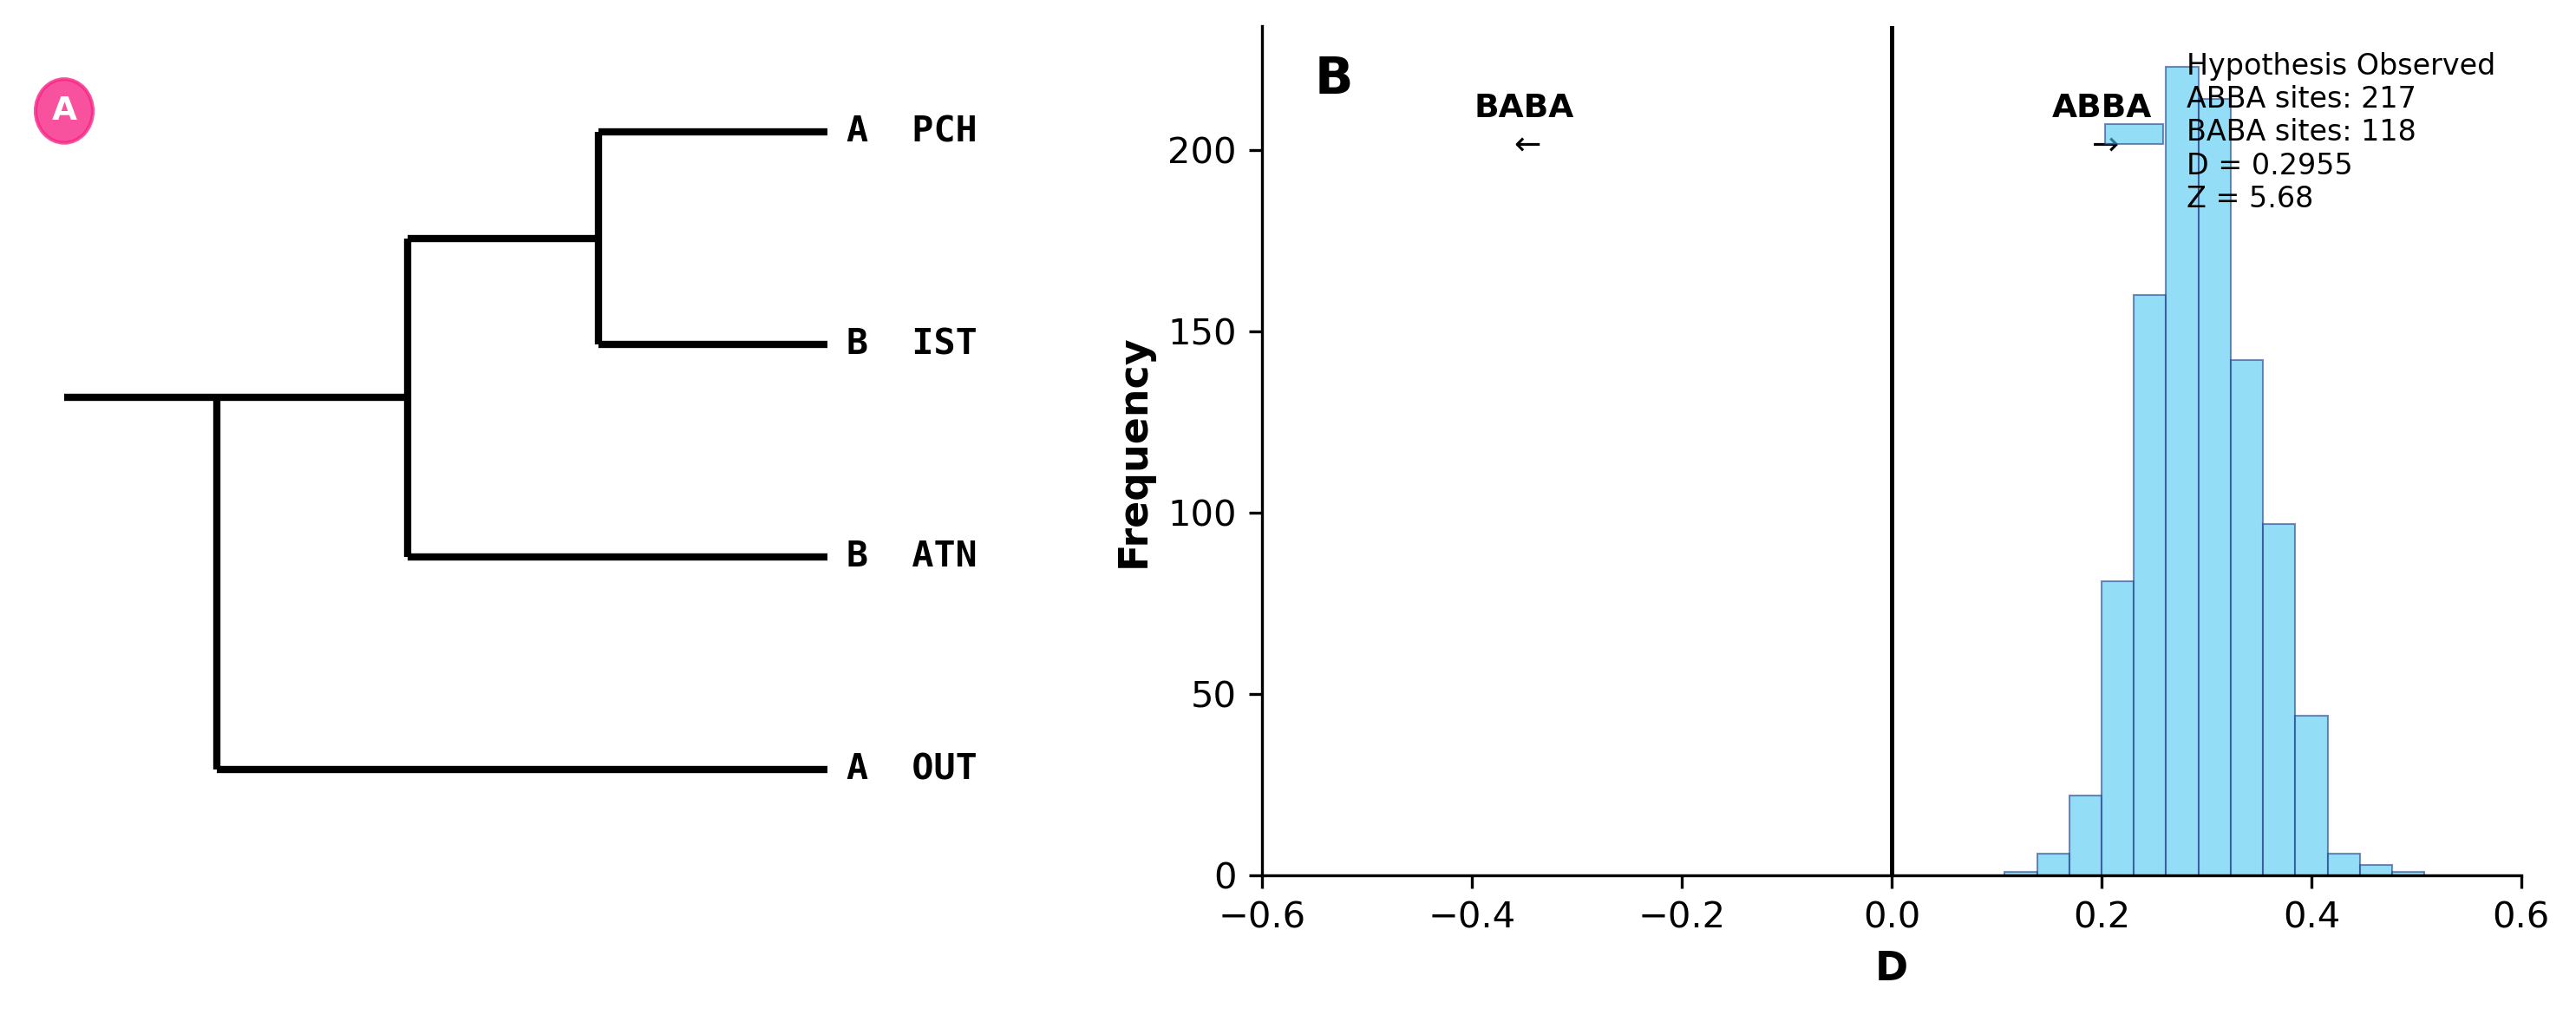

¡Figura guardada exitosamente como 'figura_compuesta_recta.png/.pdf'!


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import toytree

print("Iniciando análisis genómico e introgresión directa (Estilo Publicación)...")

# ==========================================
# 1. CARGAR Y ENRAIZAR EL ÁRBOL FILOGENÉTICO
# ==========================================
ruta_arbol = "/Users/itziliwi/JN_ABBA-BABA_micro/00_inputs/micro_iqtree_01out_20250728.nwk"
tree_obj = toytree.tree(ruta_arbol) 
muestras_en_arbol = list(tree_obj.get_tip_labels())

# Enraizar el árbol usando la API de toytree v3 (.mod.root)
arbol_enraizado = tree_obj.root("eIm_002")
arbol_string = arbol_enraizado.write()


# ==========================================
# 2. CARGAR Y FILTRAR EL MAPA DE POBLACIONES (.TSV)
# ==========================================
ruta_tsv = "/Users/itziliwi/JN_ABBA-BABA_micro/00_inputs/poblacion_260609.tsv" 
df = pd.read_csv(ruta_tsv, sep="\t", header=0)
df.columns = ["muestra", "poblacion"]
df["muestra"] = df["muestra"].astype(str).str.strip()

poblaciones_por_muestra = dict(zip(df["muestra"], df["poblacion"]))

# Listas de muestras específicas por grupo de interés
P1 = [m for m, p in poblaciones_por_muestra.items() if p == "PCH"]
P2 = [m for m, p in poblaciones_por_muestra.items() if p == "IST"]
P3 = [m for m, p in poblaciones_por_muestra.items() if p == "ATN"]
P4 = [m for m, p in poblaciones_por_muestra.items() if p == "OUT"]

ruta_loci = "/Users/itziliwi/JN_ABBA-BABA_micro/00_inputs/micro_c85_m95.loci"


# ==========================================
# 3. EXTRACCIÓN SÍNCRONA DE PATRONES EN EL .LOCI
# ==========================================
loci_data = []

with open(ruta_loci, "r") as f:
    locus_actual = {}
    for linea in f:
        linea_limpia = linea.strip()
        if not linea_limpia:
            continue
            
        if linea_limpia.startswith("//"):
            if all(any(m in locus_actual for m in group) for group in [P1, P2, P3, P4]):
                seq1 = next(locus_actual[m] for m in P1 if m in locus_actual)
                seq2 = next(locus_actual[m] for m in P2 if m in locus_actual)
                seq3 = next(locus_actual[m] for m in P3 if m in locus_actual)
                seq4 = next(locus_actual[m] for m in P4 if m in locus_actual)
                
                for n1, n2, n3, n4 in zip(seq1, seq2, seq3, seq4):
                    if '-' in (n1, n2, n3, n4) or 'N' in (n1, n2, n3, n4):
                        continue
                    # Patrón ABBA
                    if n1 == n4 and n2 == n3 and n2 != n4:
                        loci_data.append(1)
                    # Patrón BABA
                    elif n2 == n4 and n1 == n3 and n1 != n4:
                        loci_data.append(-1)
            locus_actual = {}
        else:
            parts = linea_limpia.split()
            if len(parts) == 2:
                locus_actual[parts[0].replace(">", "")] = parts[1]


# ==========================================
# 4. COMPRESIÓN ESTADÍSTICA Y BOOTSTRAP
# ==========================================
sitios_abba = loci_data.count(1)
sitios_baba = loci_data.count(-1)
total_sitios = sitios_abba + sitios_baba

if total_sitios == 0:
    print("Error: No se detectaron sitios informativos en las alineaciones.")
else:
    D = (sitios_abba - sitios_baba) / total_sitios
    
    # 1,000 repeticiones de remuestreo por bloques
    np.random.seed(26)
    arr_data = np.array(loci_data)
    boot_ds = []
    
    for _ in range(1000):
        boot_sample = np.random.choice(arr_data, size=len(arr_data), replace=True)
        n_abba = np.sum(boot_sample == 1)
        n_baba = np.sum(boot_sample == -1)
        if (n_abba + n_baba) > 0:
            boot_ds.append((n_abba - n_baba) / (n_abba + n_baba))
            
    std_err = np.std(boot_ds)
    z_score = D / std_err if std_err > 0 else 0
    
    print("\n==========================================")
    print("       RESULTADOS FINALES DEL TEST D      ")
    print("==========================================")
    print(f" Conteo Total Sitios ABBA : {sitios_abba}")
    print(f" Conteo Total Sitios BABA : {sitios_baba}")
    print(f" Estadístico D             : {D:.4f}")
    print(f" Error Estándar (Bootstrap): {std_err:.4f}")
    print(f" Z-score                   : {z_score:.4f}")
    print("==========================================\n")
    
    if abs(z_score) >= 3:
        pob_P1, pob_P2, pob_P3 = "PCH", "IST", "ATN"
        pob_flujo = pob_P2 if z_score > 0 else pob_P1
        print(f" Significancia: Flujo génico significativo entre {pob_flujo} y {pob_P3}")
    else:
        print(" Significancia: No hay evidencia de flujo génico (ILS o estructura ancestral).")
    print("==========================================")

       # ==========================================
    # 5. GENERAR FIGURA COMPUESTA CORREGIDA (RECTANGULAR Y SIN ERRORES)
    # ==========================================
    print("Renderizando figura integrada con filogenia rectangular...")
    
    # Inicializar lienzo con dos paneles (Árbol a la izquierda, Histograma a la derecha)
    fig, (ax_tree, ax_hist) = plt.subplots(1, 2, figsize=(10, 4), dpi=300, gridspec_kw={'width_ratios': [1, 1.2]})
    
    # --- PANEL A: ÁRBOL FILOGENÉTICO RECTANGULAR PERFECTO ---
    # Ramas horizontales que llegan a los taxones (Puntas)
    ax_tree.hlines(y=3.5, xmin=3.0, xmax=4.2, color='black', linewidth=2)  # P1 (ISN)
    ax_tree.hlines(y=2.5, xmin=3.0, xmax=4.2, color='black', linewidth=2)  # P2 (PCH)
    ax_tree.hlines(y=1.5, xmin=2.0, xmax=4.2, color='black', linewidth=2)  # P3 (ATN)
    ax_tree.hlines(y=0.5, xmin=1.0, xmax=4.2, color='black', linewidth=2)  # P4 (POR)
    
    # Conexiones horizontales internas entre nodos
    ax_tree.hlines(y=3.0, xmin=2.0, xmax=3.0, color='black', linewidth=2)  # Ancestro P1-P2
    ax_tree.hlines(y=2.25, xmin=1.0, xmax=2.0, color='black', linewidth=2) # Ancestro P1-P2-P3
    ax_tree.hlines(y=2.25, xmin=0.2, xmax=1.0, color='black', linewidth=2) # Tronco principal (Raíz)

    # Líneas verticales que unen los nodos (Bifurcaciones)
    ax_tree.vlines(x=3.0, ymin=2.5, ymax=3.5, color='black', linewidth=2)  # Conecta P1 y P2
    ax_tree.vlines(x=2.0, ymin=1.5, ymax=3.0, color='black', linewidth=2)  # Conecta Clado P1-P2 con P3
    ax_tree.vlines(x=1.0, ymin=0.5, ymax=2.25, color='black', linewidth=2) # Conecta todo con el Outgroup P4
    
    # Nombres de las poblaciones y estados alélicos alineados
    ax_tree.text(4.3, 3.5, "A  PCH", fontsize=10, va='center', fontweight='bold', family='monospace')
    ax_tree.text(4.3, 2.5, "B  IST", fontsize=10, va='center', fontweight='bold', family='monospace')
    ax_tree.text(4.3, 1.5, "B  ATN", fontsize=10, va='center', fontweight='bold', family='monospace')
    ax_tree.text(4.3, 0.5, "A  OUT", fontsize=10, va='center', fontweight='bold', family='monospace')
    
    # Círculo indicador decorativo del Panel A
    circulo = plt.Circle((0.2, 3.6), 0.15, color='#F72585', alpha=0.8)
    ax_tree.add_patch(circulo)
    ax_tree.text(0.2, 3.6, "A", color='white', fontsize=9, fontweight='bold', va='center', ha='center')
    
    # Ajustes de límites y apagado de ejes del panel izquierdo
    ax_tree.set_xlim(0, 5.5)
    ax_tree.set_ylim(0, 4.0)
    ax_tree.axis('off')
    
    
    # --- PANEL B: HISTOGRAMA DE FRECUENCIAS ---
    bins_eje = np.linspace(-0.6, 0.6, 40)
    color_hist = '#F72585' if abs(z_score) < 3 else '#4CC9F0'
    borde_hist = '#CD2990' if abs(z_score) < 3 else '#27408B'
    
    texto_leyenda = (
        f"Hypothesis Observed\n"
        f"ABBA sites: {sitios_abba}\n"
        f"BABA sites: {sitios_baba}\n"
        f"D = {D:.4f}\n"
        f"Z = {z_score:.2f}"
    )
    
    ax_hist.hist(
        boot_ds, 
        bins=bins_eje, 
        color=color_hist, 
        alpha=0.6, 
        edgecolor=borde_hist,
        linewidth=0.5,
        label=texto_leyenda
    )
    
    ax_hist.axvline(x=0, color='black', linewidth=1.2)
    
    # Altura máxima del histograma
    altura_max = ax_hist.get_ylim()[1]
    
    # MODIFICACIÓN AQUÍ: Reubicamos las etiquetas y flechas para que no choquen con la leyenda
    ax_hist.text(-0.35, altura_max * 0.85, r'BABA' + '\n' + r'$\leftarrow$', fontsize=9, fontweight='bold', ha='center')
    ax_hist.text(0.20, altura_max * 0.85, r'ABBA' + '\n' + r'$\rightarrow$', fontsize=9, fontweight='bold', ha='center') # <-- Movido de 0.35 a 0.20
    
    ax_hist.set_xlim(-0.6, 0.6)
    ax_hist.set_xlabel('D', fontsize=11, fontweight='bold')
    ax_hist.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    
    # MODIFICACIÓN AQUÍ: Ajustamos la leyenda para que se alinee perfectamente a la derecha externa
    ax_hist.legend(loc='upper right', fontsize=8, frameon=False, bbox_to_anchor=(1.0, 1.0))
    
    ax_hist.spines['top'].set_visible(False)
    ax_hist.spines['right'].set_visible(False)
    ax_hist.text(-0.55, altura_max * 0.92, "B", fontsize=14, fontweight='bold')

    
    plt.tight_layout()
    
    # Guardar archivos
  #  plt.savefig('figura_compuesta_recta.png', bbox_inches='tight', dpi=300)
   # plt.savefig('figura_compuesta_recta.pdf', bbox_inches='tight')
    
    plt.show()
    print("¡Figura guardada exitosamente como 'figura_compuesta_recta.png/.pdf'!")
